## Post Test Praktikum Algoritma dan Pemograman 2026
## KELAS C - HOUSING | KELOMPOK 5

**Dataset:** `Kelas C_Housing.csv`

---

## Import Library dan Load Dataset 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv(r'C:\Users\FIFMAN\Downloads\alprog test\Kelas C_Housing.csv')

# Tampilkan info dasar dataset
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])
df.head()

Jumlah baris: 545
Jumlah kolom: 13


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Kategori A (Agregasi) 
Hitung rata-rata jumlah kamar tidur dan kamar mandi sekaligus berdasarkan status furniture (furnishingstatus).

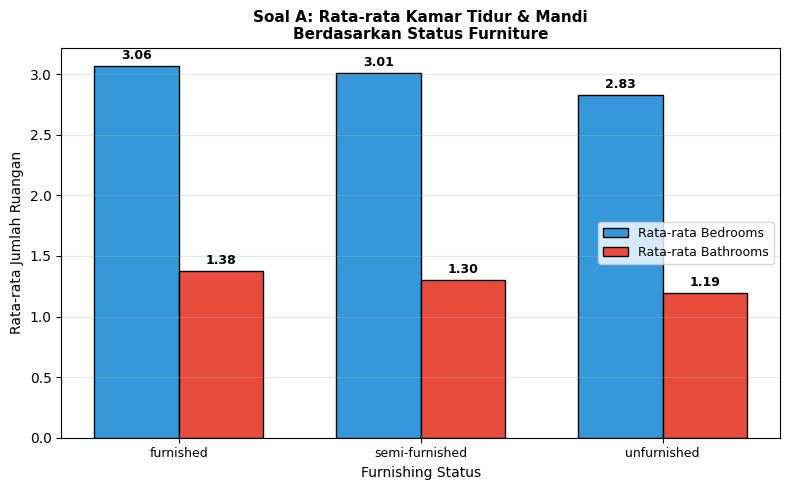

In [ ]:
def plot_kategori_a(ax):
    # Agregasi data rata-rata bedrooms dan bathrooms
    avg_rooms = df.groupby('furnishingstatus')[['bedrooms', 'bathrooms']].mean()
    
    x = np.arange(len(avg_rooms.index))
    width = 0.35
    
    
    bars1 = ax.bar(x - width/2, avg_rooms['bedrooms'], width, label='Rata-rata Bedrooms', color='#3498db', edgecolor='black')
    bars2 = ax.bar(x + width/2, avg_rooms['bathrooms'], width, label='Rata-rata Bathrooms', color='#e74c3c', edgecolor='black')
    
    
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points", ha='center', fontsize=9, fontweight='bold')
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points", ha='center', fontsize=9, fontweight='bold')
    
    
    ax.set_xlabel('Furnishing Status', fontsize=10)
    ax.set_ylabel('Rata-rata Jumlah Ruangan', fontsize=10)
    ax.set_title('Soal A: Rata-rata Kamar Tidur & Mandi\nBerdasarkan Status Furniture', fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(avg_rooms.index, fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)


fig, ax = plt.subplots(figsize=(8, 5))
plot_kategori_a(ax)
plt.tight_layout()
plt.show()

## Kategori B (Tren / Filter)
Cari rumah strategis (prefarea == 'yes') yang memiliki kamar tamu (guestroom == 'yes') namun jalannya bukan jalan utama (mainroad == 'no'). 

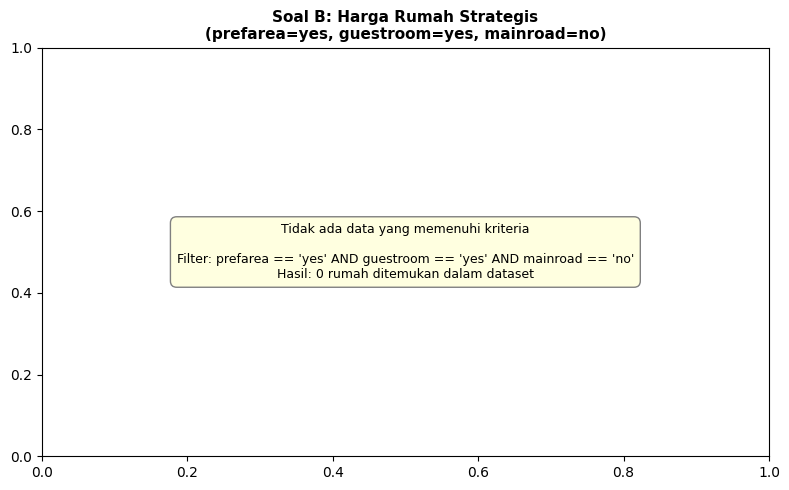

In [ ]:
def plot_kategori_b(ax):
    # Filter data sesuai kriteria
    filtered = df[
        (df['prefarea'] == 'yes') &
        (df['guestroom'] == 'yes') &
        (df['mainroad'] == 'no')
    ].copy().reset_index(drop=True)
    
    if len(filtered) > 0:
        labels = [f'Rumah {i+1}\n(Area: {row["area"]})' for i, row in filtered.iterrows()]
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(filtered)))
        bars = ax.bar(labels, filtered['price'], color=colors, edgecolor='black', width=0.6)
        
        # Tambahkan label harga di atas bar
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'Rp {height:,.0f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 5), textcoords="offset points", ha='center', fontsize=8, fontweight='bold')
        
        ax.set_xlabel('Rumah', fontsize=10)
        ax.set_ylabel('Harga (Price)', fontsize=10)
        ax.grid(axis='y', alpha=0.3)
    else:
        # Visualisasi placeholder jika hasil filter kosong (0 data)
        ax.text(0.5, 0.5, "Tidak ada data yang memenuhi kriteria\n\n"\
                "Filter: prefarea == 'yes' AND guestroom == 'yes' AND mainroad == 'no'\n"\
                "Hasil: 0 rumah ditemukan dalam dataset", 
                ha='center', va='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='gray'))
        
    ax.set_title('Soal B: Harga Rumah Strategis\n(prefarea=yes, guestroom=yes, mainroad=no)', fontsize=11, fontweight='bold')

# Tampilkan Grafik 2 (Individu)
fig, ax = plt.subplots(figsize=(8, 5))
plot_kategori_b(ax)
plt.tight_layout()
plt.show()

## Kategori C (Korelasi)
Analisis hubungan korelasi antara kapasitas tempat parkir (parking) dengan harga jual rumah (price).

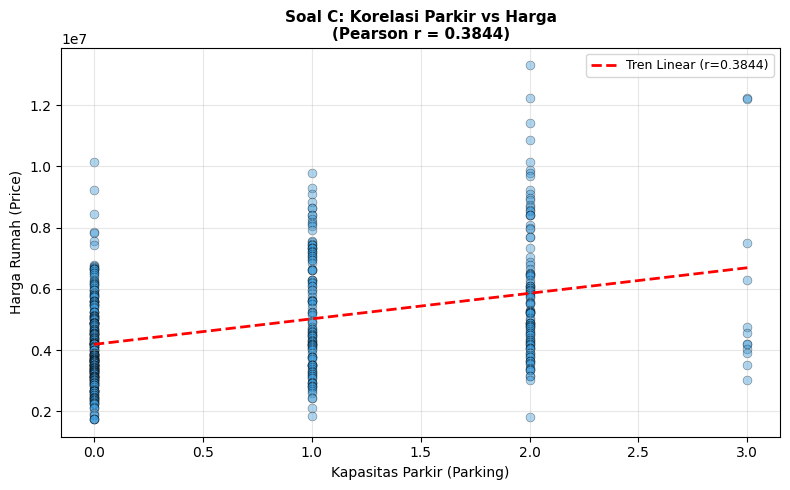

In [ ]:
def plot_kategori_c(ax):
    corr_value = df['parking'].corr(df['price'])
    
    # Scatter Plot
    ax.scatter(df['parking'], df['price'], alpha=0.4, c='#3498db', edgecolors='black', linewidth=0.5, s=40)
    
    # Menambahkan garis tren linier
    z = np.polyfit(df['parking'], df['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df['parking'].min(), df['parking'].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--', label=f'Tren Linear (r={corr_value:.4f})')
    
    ax.set_xlabel('Kapasitas Parkir (Parking)', fontsize=10)
    ax.set_ylabel('Harga Rumah (Price)', fontsize=10)
    ax.set_title(f'Soal C: Korelasi Parkir vs Harga\n(Pearson r = {corr_value:.4f})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Tampilkan Grafik 3 (Individu)
fig, ax = plt.subplots(figsize=(8, 5))
plot_kategori_c(ax)
plt.tight_layout()
plt.show()

##  Kategori D (Distribusi)
Tampilkan perbandingan sebaran harga rumah (price) berdasarkan kepemilikan fasilitas pendingin ruangan (airconditioning). 

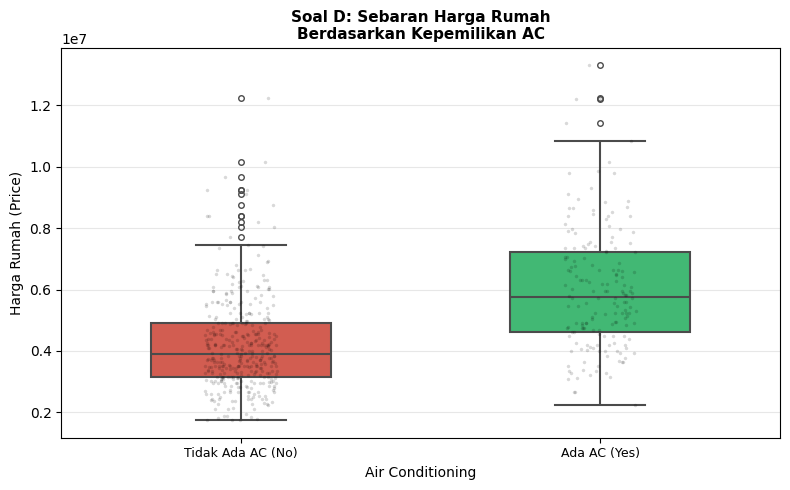

In [ ]:
def plot_kategori_d(ax):
    # Boxplot menggunakan Seaborn dengan parameter ax
    sns.boxplot(x='airconditioning', y='price', data=df, hue='airconditioning', ax=ax, 
                palette={'yes': '#2ecc71', 'no': '#e74c3c'}, width=0.5,
                linewidth=1.5, fliersize=4, legend=False, order=['no', 'yes'])
    
    # Overlay stripplot untuk menunjukkan kepadatan titik data
    sns.stripplot(x='airconditioning', y='price', data=df, ax=ax,
                  color='black', alpha=0.15, size=2.5, jitter=True, order=['no', 'yes'])
    
    ax.set_xlabel('Air Conditioning', fontsize=10)
    ax.set_ylabel('Harga Rumah (Price)', fontsize=10)
    ax.set_title('Soal D: Sebaran Harga Rumah\nBerdasarkan Kepemilikan AC', fontsize=11, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Tidak Ada AC (No)', 'Ada AC (Yes)'], fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Tampilkan Grafik 4 (Individu)
fig, ax = plt.subplots(figsize=(8, 5))
plot_kategori_d(ax)
plt.tight_layout()
plt.show()

## Grafik 5 (Gabungan) - Grid 2 X 2
Grafik gabungan yang dibuat ulang dari data dan mengikuti visual grafik 1-4. Layout menggunakan  `fig, axes = plt.subplots(2, 2, figsize=(15, 12))` dan setiap subplot  dipanggil melalui `axes[x,y]`

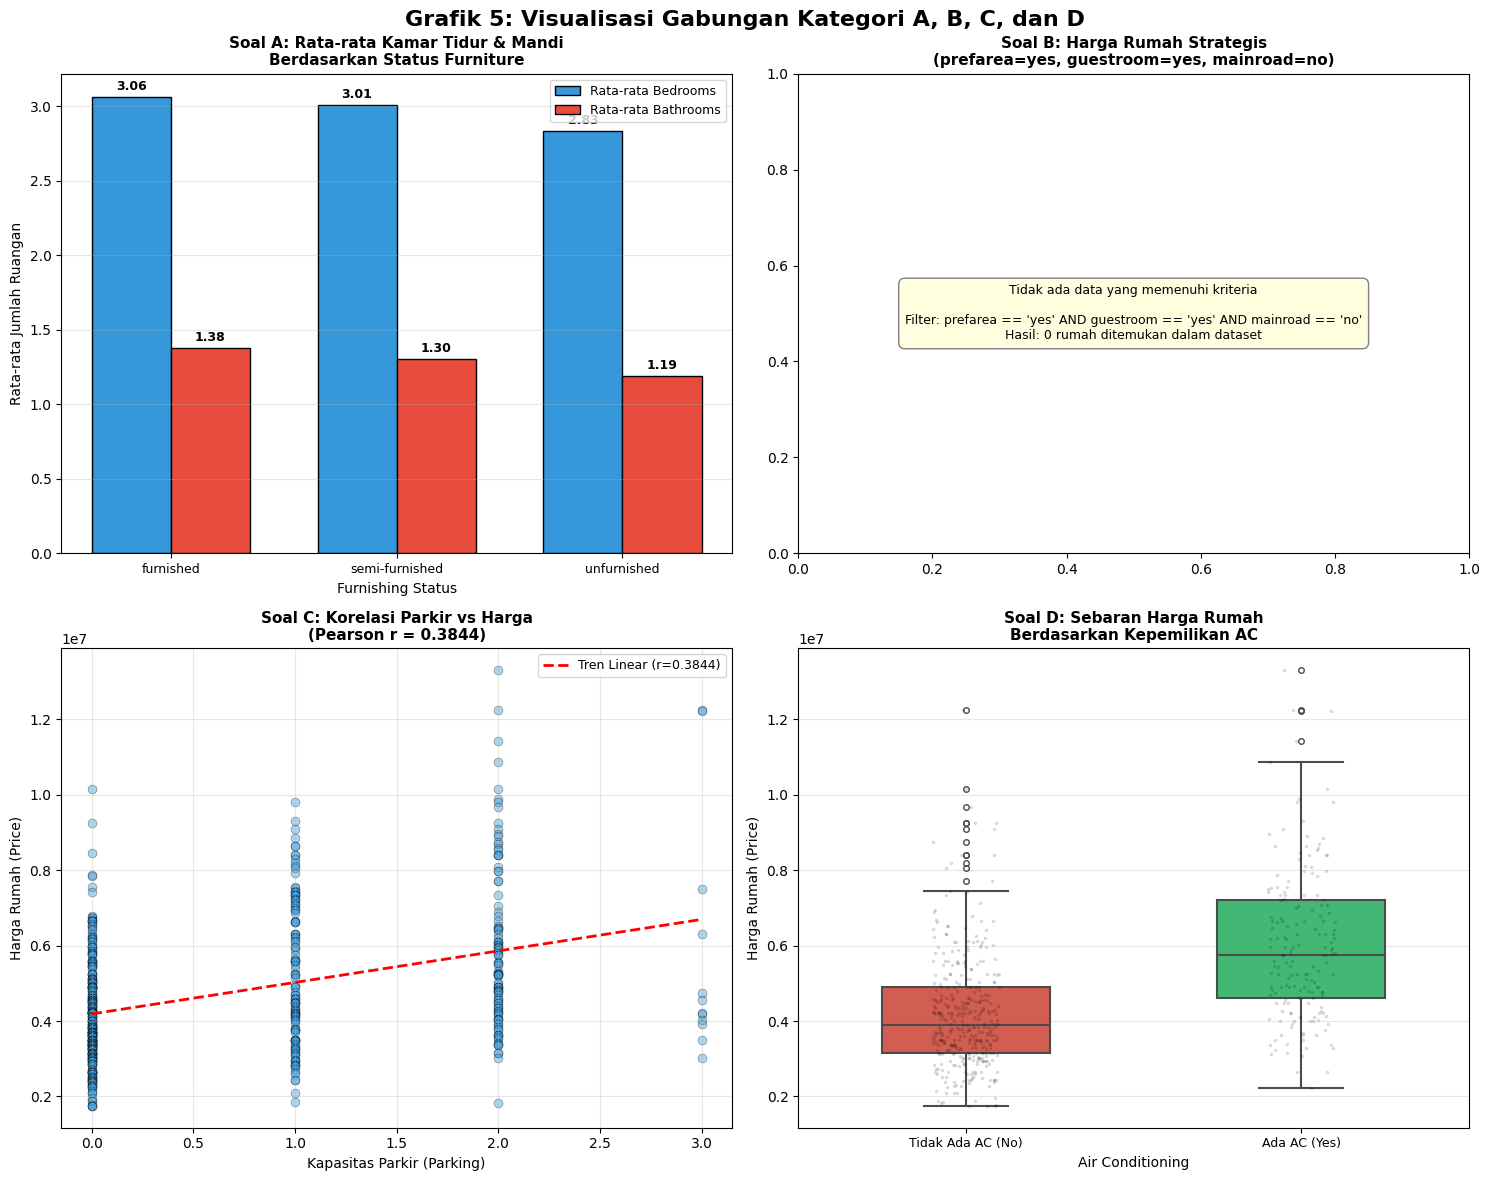

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plotting masing-masing fungsi pada grid
plot_kategori_a(axes[0, 0])
plot_kategori_b(axes[0, 1])
plot_kategori_c(axes[1, 0])
plot_kategori_d(axes[1, 1])

# Set judul utama gabungan
plt.suptitle('Grafik 5: Visualisasi Gabungan Kategori A, B, C, dan D', fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()